# CMS Hospital Rating Analysis
Udacity Data Science Nanodegree - Project 1

This project analyzes hospital quality metrics from CMS to understand what factors influence hospital overall ratings.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score



In [27]:
df = pd.read_csv("data/Hospital_General_Information.csv")

In [28]:
df.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,7,0,NaN,8,8,NaN,12,7,NaN
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,0,2,0,NaN,8,Not Available,5.0,12,6,NaN


In [29]:
df.shape

(5426, 38)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5426 entries, 0 to 5425
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5426 non-null   object 
 1   Facility Name                                     5426 non-null   object 
 2   Address                                           5426 non-null   object 
 3   City/Town                                         5426 non-null   object 
 4   State                                             5426 non-null   object 
 5   ZIP Code                                          5426 non-null   int64  
 6   County/Parish                                     5426 non-null   object 
 7   Telephone Number                                  5426 non-null   object 
 8   Hospital Type                                     5426 non-null   object 
 9   Hospital Ownership 

In [31]:
df.describe()

,ZIP Code,MORT Group Footnote,READM Group Footnote,Pt Exp Group Footnote,TE Group Footnote
count,5426.000000,1787.000000,1160.000000,2275.000000,940.000000
mean,53785.590675,11.581981,15.124138,10.162198,17.493617
std,27067.251164,7.057385,6.378223,6.808834,4.536324
min,603.000000,5.000000,5.000000,5.000000,5.000000
25%,32782.500000,5.000000,5.000000,5.000000,19.000000
50%,55063.000000,5.000000,19.000000,5.000000,19.000000
75%,76104.000000,19.000000,19.000000,19.000000,19.000000
max,99929.000000,23.000000,22.000000,22.000000,22.000000


In [32]:
df["Hospital overall rating"].value_counts()

Hospital overall rating
Not Available    2560
3                 935
4                 765
2                 649
5                 288
1                 229
Name: count, dtype: int64

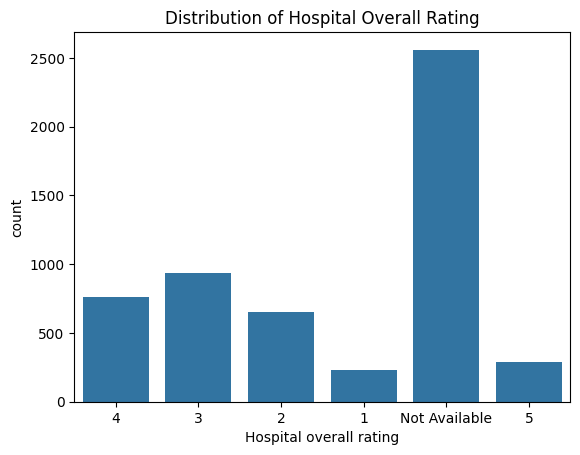

In [33]:
sns.countplot(x="Hospital overall rating", data=df)
plt.title("Distribution of Hospital Overall Rating")
plt.show()

In [34]:
df = df.replace("Not Available", np.nan)

In [35]:
df.isna().sum().sort_values(ascending=False)

TE Group Footnote                                   4486
READM Group Footnote                                4266
MORT Group Footnote                                 3639
Safety Group Footnote                               3347
Meets criteria for birthing friendly designation    3161
Pt Exp Group Footnote                               3151
Hospital overall rating footnote                    2854
Hospital overall rating                             2560
Count of Facility Pt Exp Measures                   2275
Count of Safety Measures Worse                      2073
Count of Safety Measures No Different               2073
Count of Safety Measures Better                     2073
Count of Facility Safety Measures                   2073
Count of Facility MORT Measures                     1786
Count of MORT Measures Better                       1786
Count of MORT Measures No Different                 1786
Count of MORT Measures Worse                        1786
Count of READM Measures Worse  

In [36]:
# Remove rows where the target variable (hospital rating) is missing
df = df.dropna(subset=["Hospital overall rating"])

In [37]:
# Check dataset dimensions after removing missing ratings
df.shape

(2866, 38)

In [38]:
# Count how many hospitals fall into each rating category
df["Hospital overall rating"].value_counts()

Hospital overall rating
3    935
4    765
2    649
5    288
1    229
Name: count, dtype: int64

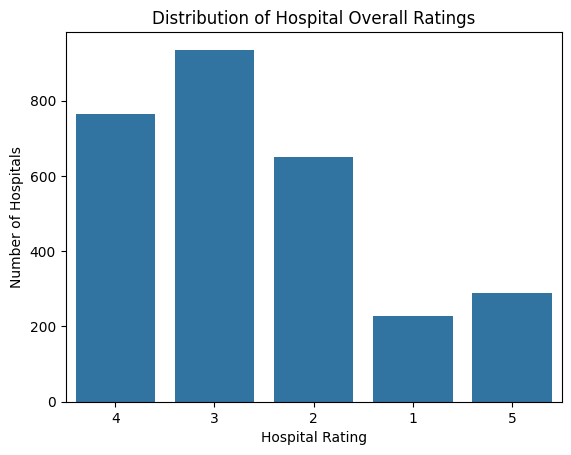

In [39]:
# Plot distribution of hospital ratings
sns.countplot(x="Hospital overall rating", data=df)

plt.title("Distribution of Hospital Overall Ratings")
plt.xlabel("Hospital Rating")
plt.ylabel("Number of Hospitals")

plt.show()

### Distribution of Hospital Ratings

Most hospitals have a rating of 3 or 4. Lower ratings (1) and higher ratings (5) are less common, indicating that most hospitals fall into the middle performance range.

In [40]:
# Convert rating to numeric
df["Hospital overall rating"] = pd.to_numeric(df["Hospital overall rating"])

In [41]:
# Convert selected performance metrics to numeric
cols = [
    "Count of MORT Measures Better",
    "Count of MORT Measures Worse",
    "Count of Safety Measures Better",
    "Count of Safety Measures Worse",
    "Count of READM Measures Better",
    "Count of READM Measures Worse",
    "Count of MORT Measures No Different"
]

for col in cols:
    df[col] = pd.to_numeric(df[col])

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2866 entries, 0 to 5405
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       2866 non-null   object 
 1   Facility Name                                     2866 non-null   object 
 2   Address                                           2866 non-null   object 
 3   City/Town                                         2866 non-null   object 
 4   State                                             2866 non-null   object 
 5   ZIP Code                                          2866 non-null   int64  
 6   County/Parish                                     2866 non-null   object 
 7   Telephone Number                                  2866 non-null   object 
 8   Hospital Type                                     2866 non-null   object 
 9   Hospital Ownership      

In [43]:
df.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type',
       'Hospital Ownership', 'Emergency Services',
       'Meets criteria for birthing friendly designation',
       'Hospital overall rating', 'Hospital overall rating footnote',
       'MORT Group Measure Count', 'Count of Facility MORT Measures',
       'Count of MORT Measures Better', 'Count of MORT Measures No Different',
       'Count of MORT Measures Worse', 'MORT Group Footnote',
       'Safety Group Measure Count', 'Count of Facility Safety Measures',
       'Count of Safety Measures Better',
       'Count of Safety Measures No Different',
       'Count of Safety Measures Worse', 'Safety Group Footnote',
       'READM Group Measure Count', 'Count of Facility READM Measures',
       'Count of READM Measures Better',
       'Count of READM Measures No Different', 'Count of READM Measures Worse',
       'READM Group Footnote', 'Pt Exp Gr

In [44]:
# Select numeric columns for correlation analysis
cols = [
    "Hospital overall rating",
    "Count of MORT Measures Better",
    "Count of MORT Measures Worse",
    "Count of MORT Measures No Different",
    "Count of Safety Measures Better",
    "Count of Safety Measures Worse",
    "Count of READM Measures Better",
    "Count of READM Measures Worse"
]

numeric_df = df[cols]

In [45]:
# Compute correlation matrix
corr = numeric_df.corr()

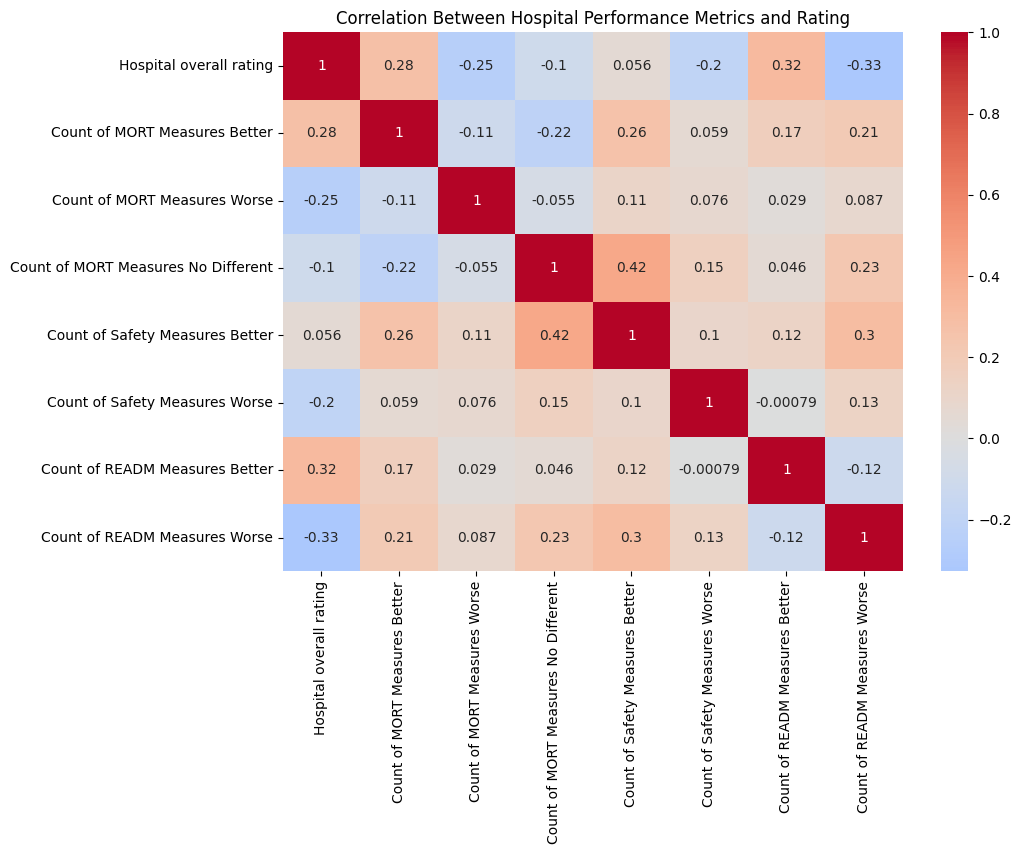

In [46]:
# Plot correlation heatmap
plt.figure(figsize=(10,7))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            center=0)

plt.title("Correlation Between Hospital Performance Metrics and Rating")
plt.show()

### Correlation Insights

The correlation analysis shows that readmission and mortality performance metrics have the strongest relationships with hospital overall ratings.

Hospitals with more measures categorized as "Better" tend to have higher ratings, while hospitals with more measures categorized as "Worse" tend to have lower ratings.

Although the correlations are moderate, these variables may still provide useful predictive information for a machine learning model.

In [47]:
# Define target variable
y = df["Hospital overall rating"]

# Define feature variables
X = df[[
    "Count of MORT Measures Better",
    "Count of MORT Measures Worse",
    "Count of MORT Measures No Different",
    "Count of Safety Measures Better",
    "Count of Safety Measures Worse",
    "Count of READM Measures Better",
    "Count of READM Measures Worse"
]]

In [48]:
# Check missing values in selected features
X.isna().sum()

Count of MORT Measures Better          53
Count of MORT Measures Worse           53
Count of MORT Measures No Different    53
Count of Safety Measures Better        85
Count of Safety Measures Worse         85
Count of READM Measures Better          1
Count of READM Measures Worse           1
dtype: int64

In [49]:
# Remove rows with missing values
X = X.dropna()
y = y.loc[X.index]

In [52]:

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [55]:
# Create Random Forest model
model = RandomForestClassifier(random_state=42)

In [56]:
# Train the model using training data
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [59]:
# Predict ratings on the test set
y_pred = model.predict(X_test)

In [60]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.39377289377289376

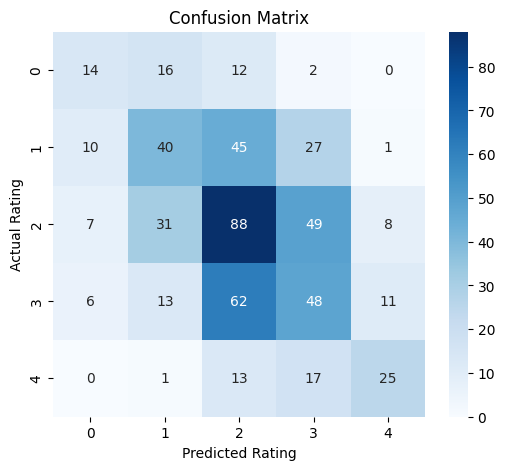

In [63]:
# Plot confusion matrix to evaluate classification performance

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")

plt.show()

In [64]:
# Identify which variables influence the prediction the most

# Get feature importance from the model
importances = model.feature_importances_

# Create dataframe for visualization
feature_importance = pd.Series(importances, index=X.columns)

# Sort features
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance

Count of Safety Measures Better        0.227624
Count of MORT Measures No Different    0.225329
Count of READM Measures Worse          0.166061
Count of READM Measures Better         0.123791
Count of MORT Measures Better          0.102578
Count of Safety Measures Worse         0.080716
Count of MORT Measures Worse           0.073902
dtype: float64

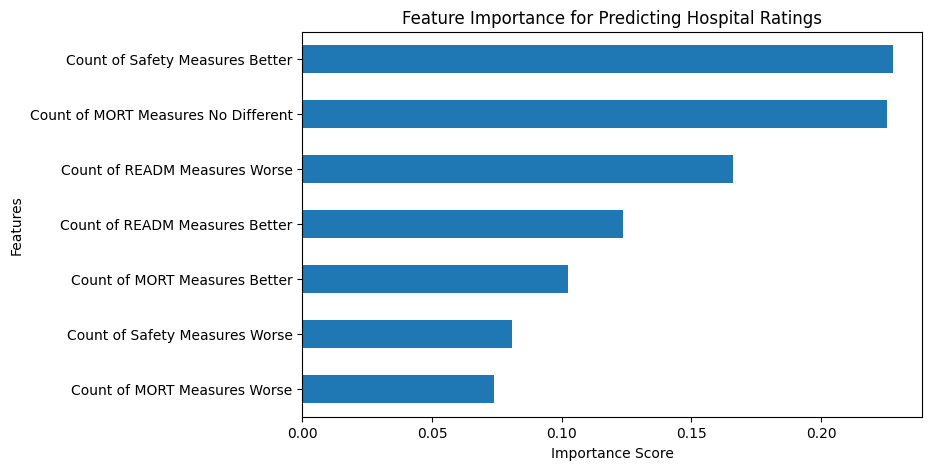

In [65]:
# Plot feature importance

plt.figure(figsize=(8,5))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Predicting Hospital Ratings")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [67]:
# Generate precision, recall and F1-score for each rating class

# Evaluate model with detailed classification metrics
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.38      0.32      0.35        44
           2       0.40      0.33      0.36       123
           3       0.40      0.48      0.44       183
           4       0.34      0.34      0.34       140
           5       0.56      0.45      0.50        56

    accuracy                           0.39       546
   macro avg       0.41      0.38      0.39       546
weighted avg       0.40      0.39      0.39       546



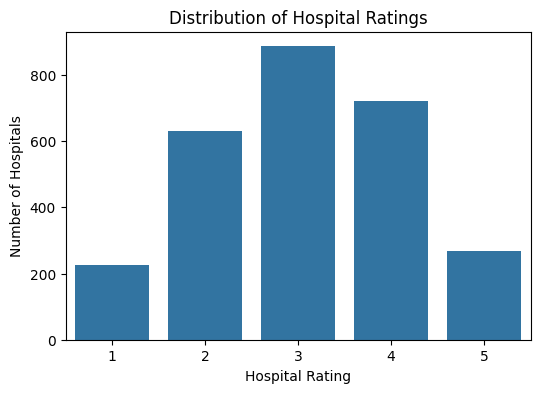

In [68]:
# Plot distribution of hospital ratings

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Distribution of Hospital Ratings")
plt.xlabel("Hospital Rating")
plt.ylabel("Number of Hospitals")

plt.show()

In [69]:
# Predict on training data
y_train_pred = model.predict(X_train)

# Compute training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

train_accuracy

0.5971585701191567